In [1]:
import sys

import pandas as pd

In [28]:

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
display(df.head())
df.info()
display(df.describe())
df.shape

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


(1200, 13)

In [29]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

depression_label
0    1169
1      31
Name: count, dtype: int64

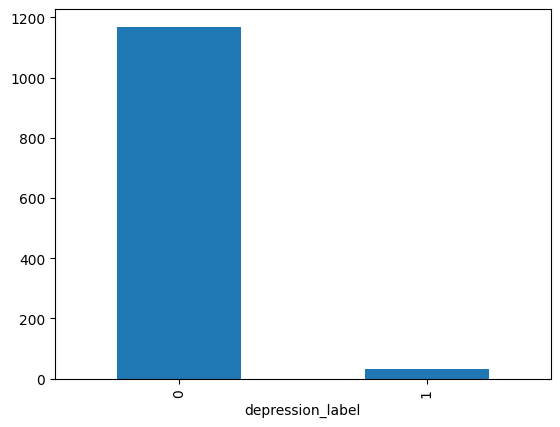

In [30]:

counts = df['depression_label'].value_counts()
counts.plot.bar()
counts

The dataset is severely imbalanced, with the positive class (depression_label=1) representing only 2.6% of samples. This limits the usefulness of accuracy as an evaluation metric, motivating our choice of F1 and ROC-AUC, and requires the use of stratified sampling and class-weighted models.

In [31]:
X = df.drop(columns=['depression_label'])   # 拿掉答案那欄,剩下都是線索
y = df['depression_label']                  # 只挑「答案」那欄
X.shape, y.shape                             # 確認形狀

((1200, 12), (1200,))

In [32]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head(10)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,0,1
5,19,7.4,4.4,2.4,2.63,0.6,3,5,7,0,0,0,0,0
6,18,2.5,6.4,2.4,2.63,0.7,2,2,5,0,1,0,1,0
7,16,4.0,4.2,0.5,2.40,1.3,6,10,5,1,0,0,1,0
8,19,3.3,5.0,2.1,2.04,0.9,1,10,9,0,0,1,0,0
9,15,1.9,4.9,1.5,3.77,1.1,1,1,4,1,0,1,0,0


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((960, 14), (240, 14))

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train.shape, X_test.shape

((960, 14), (240, 14))

In [35]:
from sklearn.linear_model import SGDClassifier

In [36]:
import numpy as np
from sklearn.metrics import fbeta_score, make_scorer, precision_score, recall_score, confusion_matrix

def find_best_threshold(proba, y_test, beta=2.0):

    thresholds = np.arange(0.001, 0.953, 0.001)

    best_t = None
    best_f2 = -1

    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        f2 = fbeta_score(y_test, y_pred, beta=beta)

        if f2 > best_f2:
            best_f2 = f2
            best_t = t

    y_pred_best = (proba >= best_t).astype(int)
    cm = confusion_matrix(y_test, y_pred_best)

    return {
        "best_threshold": best_t,
        "y_pred": y_pred_best,
        "best_f2": best_f2,
        "precision": precision_score(y_test, y_pred_best),
        "recall": recall_score(y_test, y_pred_best),
        "confusion_matrix": cm
    }

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, roc_curve, auc
)

def get_scores(classifier, X_test, y_test=y_test):
    X_test = X_test if X_test is not None else X_test
    proba = classifier.predict_proba(X_test)[:, 1]
    result = find_best_threshold(proba, y_test)
    # y_pred = classifier.predict(X_test)
    # f2 = fbeta_score(y_test, y_pred, beta=2)
    # f1 = f1_score(y_test, y_pred)
    # recall = recall_score(y_test, y_pred)
    # roc_auc = roc_auc_score(y_test, proba)
    # accuracy = accuracy_score(y_test, y_pred)
    # precision = precision_score(y_test, y_pred)
    y_pred = result['y_pred']
    f2 = result['best_f2']
    recall = result['recall']
    precision = result['precision']
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, proba)
    accuracy = accuracy_score(y_test, y_pred)
    print("F2:", f2, "\nRecall:", recall, "\nF1:", f1, "\nROC AUC:", roc_auc, "\nAccuracy:", accuracy, "\nPrecision:", precision)
    # print(classification_report(y_test, y_pred))
    # print(result)
    se = pd.Series([y_pred, proba, f2, recall, f1, accuracy, roc_auc, precision], index=['y_pred', 'proba', 'F2', 'Recall', 'F1', 'Accuracy', 'ROC AUC', 'Precision'])

    return se

def plot_confusion_matrix(y_pred, y_test=y_test):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
    plt.show()

metrics = ['F2', 'Recall', 'F1', 'Accuracy', 'ROC AUC', 'Precision']
def compare_multiple_scores(metrics, before_scores, after_scores_list, labels=None, title="Performance Comparison"):
    """
    compare GridSearchCV before and after scores for multiple models.
    
    metrics: list of str, labels, ex ['Accuracy','F1','ROC-AUC']
    before_scores: list of float, baseline scores for each metric, ex [0.92, 0.90, 0.93]
    after_scores_list: list of list, each after_scores, ex [[0.95,0.88,0.91],[0.96,0.89,0.92]]
    labels: list of str, each after_scores label, ex ['Model A','Model B']
    title: str, chart title
    """
    x = np.arange(len(metrics))
    width = 0.15  # each bar width
    
    plt.figure(figsize=(12,6))
    
    # baseline (Before)
    plt.bar(x - width, before_scores, width, label='Before', color='skyblue')
    
    # models After
    for i, scores in enumerate(after_scores_list):
        offset = (i) * width
        plt.bar(x + offset, scores, width, label=labels[i] if labels else f'After {i+1}')
        # at each bar, show the value
        for j, v in enumerate(scores):
            plt.text(j + offset, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    # baseline value labels
    for j, v in enumerate(before_scores):
        plt.text(j - width, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=8)
    
    plt.xticks(x, metrics)
    plt.ylabel('Score')
    plt.ylim(0, 1.1)
    plt.title(title)
    plt.legend()
    plt.show()

def plot_roc_curve(y_score, y_test=y_test):
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'k--', alpha=0.6)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve'); plt.legend(); plt.show()

In [63]:
def evaluate_fit(model, X_train, y_train, X_test, y_test, beta=2.0):
    # ---------- training set ----------
    proba_train = model.predict_proba(X_train)[:, 1]
    y_pred_train = (proba_train >= 0.5).astype(int)

    train_f2 = fbeta_score(y_train, y_pred_train, beta=beta)
    train_recall = recall_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_acc = accuracy_score(y_train, y_pred_train)
    train_auc = roc_auc_score(y_train, proba_train)

    # ---------- testing set ----------
    proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = (proba_test >= 0.5).astype(int)

    test_f2 = fbeta_score(y_test, y_pred_test, beta=beta)
    test_recall = recall_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, proba_test)

    # ---------- print results ----------
    print("=== Train Scores ===")
    print(f"F2: {train_f2:.4f}, Recall: {train_recall:.4f}, Precision: {train_precision:.4f}, "
          f"Accuracy: {train_acc:.4f}, ROC-AUC: {train_auc:.4f}")

    print("\n=== Test Scores ===")
    print(f"F2: {test_f2:.4f}, Recall: {test_recall:.4f}, Precision: {test_precision:.4f}, "
          f"Accuracy: {test_acc:.4f}, ROC-AUC: {test_auc:.4f}")

    # ---------- model diagnosis ----------
    print("\n=== Model Diagnosis ===")

    # score gaps
    f2_gap = train_f2 - test_f2
    auc_gap = train_auc - test_auc

    # Overfitting
    if train_f2 > 0.8 and f2_gap > 0.15:
        print("⚠️ model Overfitting：training score is high but testing score is significantly lower")
    # Underfitting
    elif train_f2 < 0.6 and test_f2 < 0.6:
        print("⚠️ model Underfitting：training and testing scores are both low, model is not learning well")
    # normal
    else:
        print("✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting")

    return {
        "train_f2": train_f2,
        "test_f2": test_f2,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "diagnosis": "overfit" if train_f2 > 0.8 and f2_gap > 0.15 else
                     "underfit" if train_f2 < 0.6 and test_f2 < 0.6 else
                     "good"
    }

After SMOTE training data distribution: Counter({0: 935, 1: 935})
F2: 0.8823529411764706 
Recall: 1.0 
F1: 0.7499999999999999 
ROC AUC: 0.9943019943019943 
Accuracy: 0.9833333333333333 
Precision: 0.6


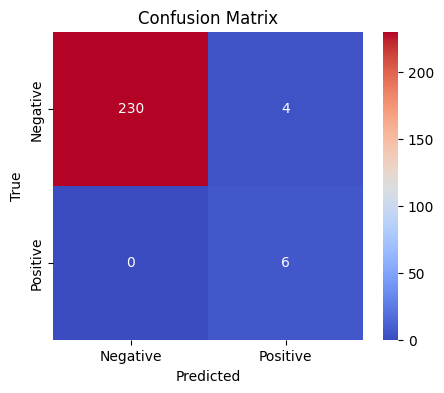

=== Train Scores ===
F2: 0.7692, Recall: 0.9600, Precision: 0.4286, Accuracy: 0.9656, ROC-AUC: 0.9908

=== Test Scores ===
F2: 0.6250, Recall: 0.6667, Precision: 0.5000, Accuracy: 0.9750, ROC-AUC: 0.9943

=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'train_f2': 0.7692307692307693,
 'test_f2': 0.625,
 'train_auc': 0.9908021390374332,
 'test_auc': 0.9943019943019943,
 'diagnosis': 'good'}

In [115]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

sgd_clf = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42, verbose=0)
sgd_model = sgd_clf
pipe_sgd = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', sgd_clf)
])
pipe_sgd.fit(X_train, y_train)

smote_step = pipe_sgd.named_steps['smote']
X_resampled, y_resampled = smote_step.fit_resample(X_train, y_train)
print("After SMOTE training data distribution:", Counter(y_resampled))

pipe_sgd_result = get_scores(pipe_sgd)
plot_confusion_matrix(pipe_sgd_result['y_pred'])

evaluate_fit(pipe_sgd, X_train, y_train, X_test, y_test)


Best params: {'clf__max_iter': 100, 'clf__penalty': 'l2'}
F2: 0.8823529411764706 
Recall: 1.0 
F1: 0.7499999999999999 
ROC AUC: 0.9943019943019943 
Accuracy: 0.9833333333333333 
Precision: 0.6


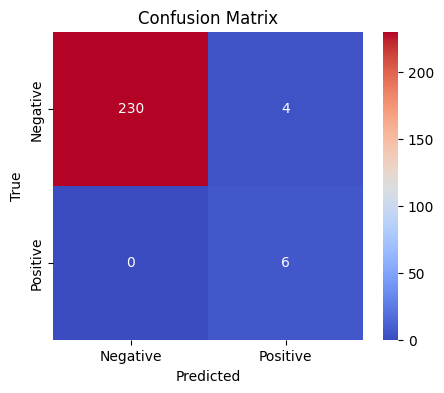

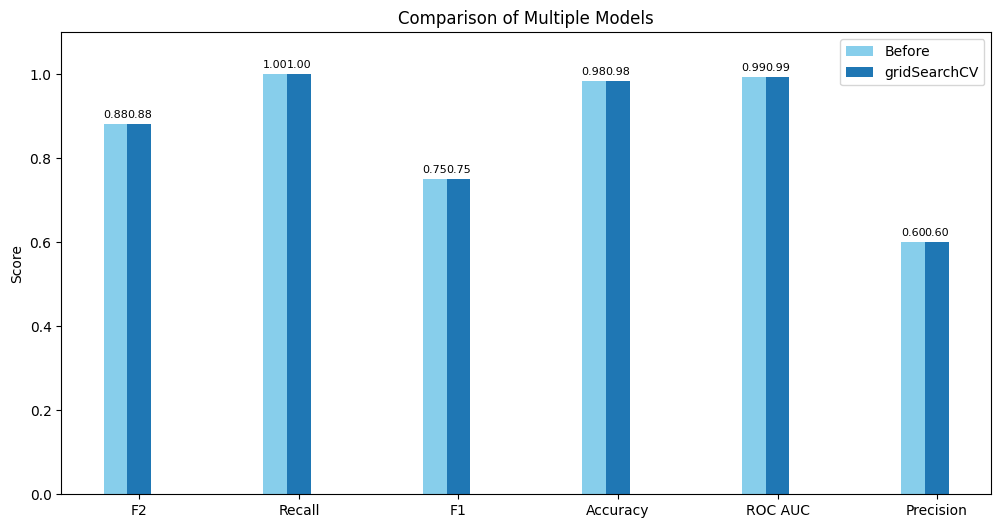

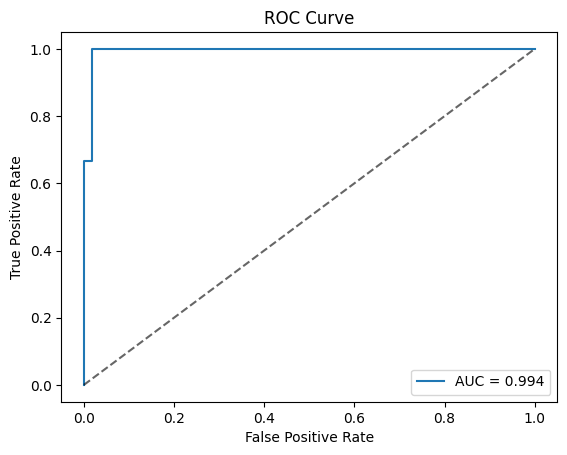

=== Train Scores ===
F2: 0.7692, Recall: 0.9600, Precision: 0.4286, Accuracy: 0.9656, ROC-AUC: 0.9908

=== Test Scores ===
F2: 0.6250, Recall: 0.6667, Precision: 0.5000, Accuracy: 0.9750, ROC-AUC: 0.9943

=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'train_f2': 0.7692307692307693,
 'test_f2': 0.625,
 'train_auc': 0.9908021390374332,
 'test_auc': 0.9943019943019943,
 'diagnosis': 'good'}

In [116]:
import warnings
from sklearn.exceptions import ConvergenceWarning, FitFailedWarning

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    warnings.simplefilter("ignore", category=FitFailedWarning)

param_grid = {
    'clf__penalty': ['l2', 'l1', 'elasticnet'],
    'clf__max_iter': [50, 100, 500, 1000]
}

def f2_with_threshold_scorer(estimator, X, y):
    # 1. get predicted probabilities from the estimator
    proba = estimator.predict_proba(X)[:, 1]

    # 2. use find_best_threshold() to find the best threshold
    result = find_best_threshold(proba, y, beta=2.0)

    # 3. return the F2-score to GridSearchCV
    return result["best_f2"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #use stratified K-fold cross-validation to ensure consistent class distribution in each fold, leading to more reliable model evaluation results

grid = GridSearchCV(
    estimator=pipe_sgd,
    param_grid=param_grid,
    scoring=f2_with_threshold_scorer, #use F2 score as the evaluation metric, as it better balances precision and recall when dealing with imbalanced data
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train) #in the training data to perform grid search and find the best hyperparameter combination, thereby improving the model's performance and generalization ability

print("Best params:", grid.best_params_)

grid_model = grid.best_estimator_
gridSearchCV_Series = get_scores(grid_model)
plot_confusion_matrix(gridSearchCV_Series['y_pred'])

before = [pipe_sgd_result['F2'], pipe_sgd_result['Recall'], pipe_sgd_result['F1'], pipe_sgd_result['Accuracy'], pipe_sgd_result['ROC AUC'], pipe_sgd_result['Precision']]
after_list = [
    [gridSearchCV_Series['F2'], gridSearchCV_Series['Recall'], gridSearchCV_Series['F1'], gridSearchCV_Series['Accuracy'], gridSearchCV_Series['ROC AUC'], gridSearchCV_Series['Precision']]
]
labels = ['gridSearchCV']

compare_multiple_scores(metrics, before, after_list, labels, title="Comparison of Multiple Models")

plot_roc_curve(grid_model.decision_function(X_test))

evaluate_fit(grid_model, X_train, y_train, X_test, y_test)

F2: 0.8571428571428571 
Recall: 1.0 
F1: 0.7058823529411764 
ROC AUC: 0.9914529914529914 
Accuracy: 0.9791666666666666 
Precision: 0.5454545454545454


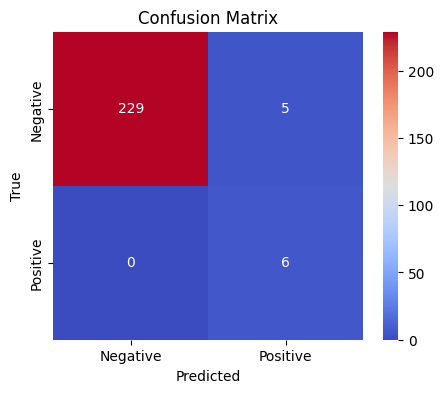

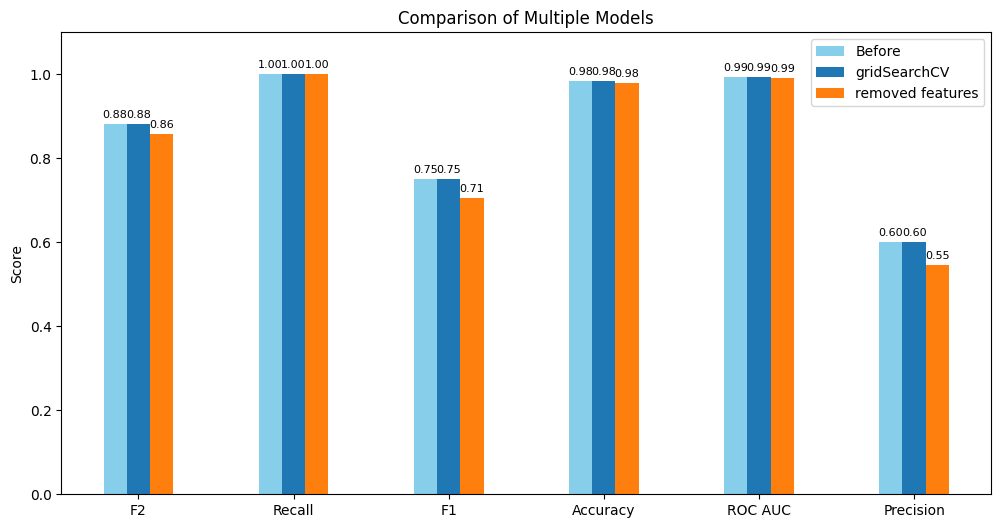

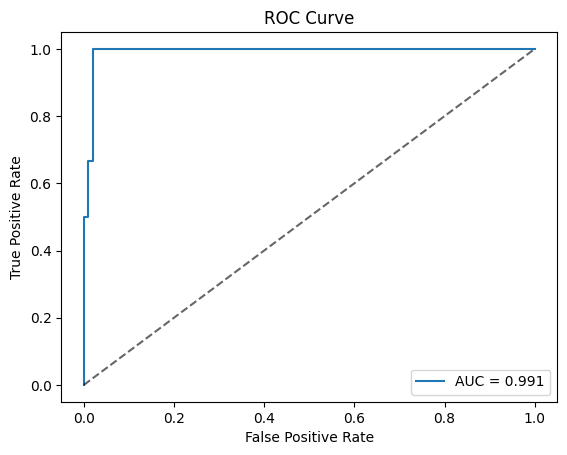

=== Train Scores ===
F2: 0.7006, Recall: 0.8800, Precision: 0.3860, Accuracy: 0.9604, ROC-AUC: 0.9892

=== Test Scores ===
F2: 0.7353, Recall: 0.8333, Precision: 0.5000, Accuracy: 0.9750, ROC-AUC: 0.9915

=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'train_f2': 0.7006369426751592,
 'test_f2': 0.7352941176470589,
 'train_auc': 0.9892192513368984,
 'test_auc': 0.9914529914529914,
 'diagnosis': 'good'}

In [119]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif,RFE
from sklearn.pipeline import Pipeline

# pipe = Pipeline([
#     ('select', SelectKBest(score_func=mutual_info_classif)),
#     ('scaler', StandardScaler()),
#     ('clf', sgd_clf)
# ])

pipe = ImbPipeline([
    # ('select', SelectKBest(score_func=f_classif)),
    ('rfe', RFE(estimator=sgd_clf)),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', sgd_clf)
])

param_grid_pipe = {
    'rfe__n_features_to_select': [5, 6, 7, 8],
    # 'clf__max_iter': [ 50, 100, 500, 1000],
    # 'clf__alpha': [1e-5, 1e-2, 1e-3],
    'smote__k_neighbors': [ 7, 10, 15]
}

# param_grid_pipe = {
#     'select__k': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
#     # 'clf__C': [0.01, 0.1, 1, 10]
#     'clf__penalty': ['l2', 'l1', 'elasticnet'],
#     'clf__alpha': [1e-4, 1e-3, 1e-2],
#     # 'clf__l1_ratio': [0.0, 0.5, 1.0],
#     # 'clf__class_weight': [None, 'balanced']
# }

grid_pipe = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid_pipe,
    scoring=f2_with_threshold_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0 )

grid_pipe.fit(X_train, y_train)

# print("Best params:", grid_pipe.best_params_)
grid_model = grid_pipe.best_estimator_

# def print_full_best_params(grid):
#     print("=== Best Parameters (GridSearchCV selected) ===")
#     for k, v in grid.best_params_.items():
#         print(f"{k}: {v}")

#     print("\n=== Full Parameter Set (including defaults) ===")
#     best_est = grid.best_estimator_

#     full_params = best_est.get_params()
#     for k, v in full_params.items():
#         mark = "(tuned)" if k in grid.best_params_ else "(default)"
#         print(f"{k}: {v} {mark}")

# print_full_best_params(grid_pipe)


best_model_Series = get_scores(grid_model)
plot_confusion_matrix(best_model_Series['y_pred'])

after_list = [
    [gridSearchCV_Series['F2'], gridSearchCV_Series['Recall'], gridSearchCV_Series['F1'], gridSearchCV_Series['Accuracy'], gridSearchCV_Series['ROC AUC'], gridSearchCV_Series['Precision']],
    [best_model_Series['F2'], best_model_Series['Recall'], best_model_Series['F1'], best_model_Series['Accuracy'], best_model_Series['ROC AUC'], best_model_Series['Precision']]
]
# after_list.append([best_model_Series['F2'], best_model_Series['Recall'], best_model_Series['F1'], best_model_Series['Accuracy'], best_model_Series['ROC AUC'], best_model_Series['Precision']])

labels = ['gridSearchCV', 'removed features']

compare_multiple_scores(metrics, before, after_list, labels, title="Comparison of Multiple Models")

plot_roc_curve(grid_model.decision_function(X_test))

# print(grid_pipe.cv_results_['param_rfe__n_features_to_select'])

# best_selector = grid_pipe.best_estimator_.named_steps['select']
# mask = best_selector.get_support()   # True/False mask
# selected_features = X.columns[mask]
# print("Selected features:", selected_features)

# results = pd.DataFrame(grid_pipe.cv_results_)
# # print(results.columns)
# print(results[['rank_test_score', 'param_select__k','mean_test_score','std_test_score', 'params']].sort_values('rank_test_score').head(10))


# k_scores = results[['param_select__k', 'mean_test_score']].sort_values('param_select__k')
# print(k_scores)

# plt.figure(figsize=(8,5))
# plt.plot(k_scores['param_select__k'], k_scores['mean_test_score'], marker='o')
# plt.xlabel('Number of Selected Features (k)')
# plt.ylabel('F2-score (CV mean)')
# plt.title('k vs F2-score')
# plt.grid(True)
# plt.show()

evaluate_fit(grid_model, X_train, y_train, X_test, y_test)

Best params: {}
F2: 0.8064516129032258 
Recall: 0.8333333333333334 
F1: 0.7692307692307692 
ROC AUC: 0.9871794871794872 
Accuracy: 0.9875 
Precision: 0.7142857142857143


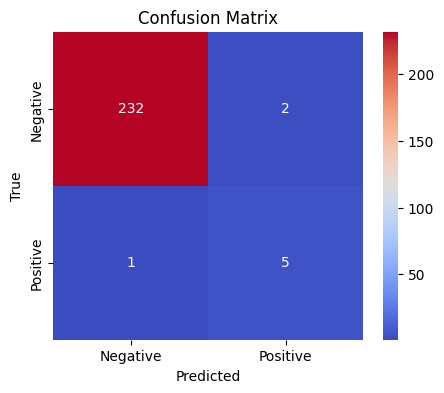

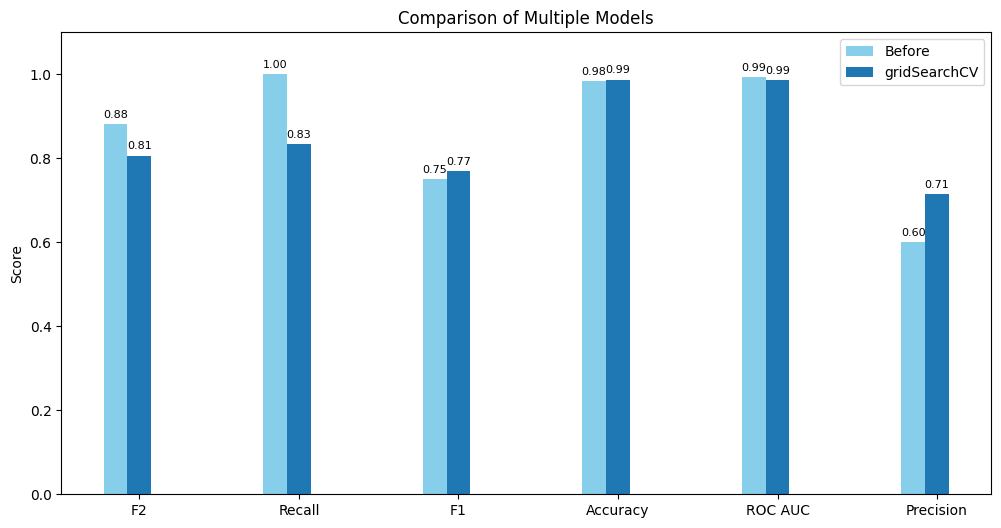

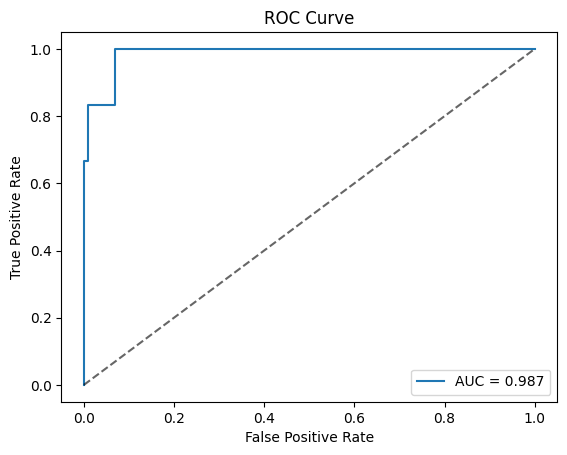

=== Train Scores ===
F2: 0.6383, Recall: 0.9600, Precision: 0.2727, Accuracy: 0.9323, ROC-AUC: 0.9864

=== Test Scores ===
F2: 0.6410, Recall: 0.8333, Precision: 0.3333, Accuracy: 0.9542, ROC-AUC: 0.9872

=== Model Diagnosis ===
✅ model performance is normal：training and testing scores are close, no obvious overfitting or underfitting


{'train_f2': 0.6382978723404256,
 'test_f2': 0.6410256410256411,
 'train_auc': 0.9863957219251337,
 'test_auc': 0.9871794871794872,
 'diagnosis': 'good'}

In [ ]:
feature_names = X.columns
selected_features = ['sleep_hours', 'stress_level', 'anxiety_level', 'daily_social_media_hours', 'screen_time_before_sleep', 'gender', 'addiction_level']
mask = [f in selected_features for f in feature_names]
X_train_selected = X_train[:, mask]

pipe_selected = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', sgd_clf)
])

param_grid = {
    # 'clf__penalty': ['l2', 'l1', 'elasticnet'],
    # 'clf__max_iter': [50, 100, 500, 1000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_selected,
    param_grid=param_grid,
    scoring=f2_with_threshold_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_selected, y_train)

print("Best params:", grid.best_params_)

grid_model = grid.best_estimator_
gridSearchCV_Series = get_scores(grid_model, X_test[:, mask])
plot_confusion_matrix(gridSearchCV_Series['y_pred'])

before = [pipe_sgd_result['F2'], pipe_sgd_result['Recall'], pipe_sgd_result['F1'], pipe_sgd_result['Accuracy'], pipe_sgd_result['ROC AUC'], pipe_sgd_result['Precision']]
after_list = [
    [gridSearchCV_Series['F2'], gridSearchCV_Series['Recall'], gridSearchCV_Series['F1'], gridSearchCV_Series['Accuracy'], gridSearchCV_Series['ROC AUC'], gridSearchCV_Series['Precision']]
]
labels = ['gridSearchCV']

compare_multiple_scores(metrics, before, after_list, labels, title="Comparison of Multiple Models")

plot_roc_curve(grid_model.decision_function(X_test[:, mask]))

evaluate_fit(grid_model, X_train_selected, y_train, X_test[:, mask], y_test)
